In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import myUtils
import EfficientNet
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import utils as utils
from GTSRB_utils import GTSRB_CLASSES, predict_traffic_sign, create_subset_loader

2025-02-19 19:40:18.862798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-19 19:40:19.308529: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-19 19:40:19.456741: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-19 19:40:20.061302: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-19 19:40:23.744671: W tensorflow/compiler/tf2

Padding needed: (2, 2)


In [2]:
data_dir = "GTSRB/Final_Training/Images"  # Path to training folder
test_dir = "GTSRB/Final_Test/Images"    # Path to testing folder
batch_size = 32
target_size = (240, 240)


# Define augmentation for training data
train_datagen = ImageDataGenerator(          # Normalize pixel values to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,
    validation_split=0.2      # Reserve 20% for validation
)

# Generator for validation (no augmentation, same normalization)
val_datagen = ImageDataGenerator(           # Match training normalization
    validation_split=0.1
)

# Generator for testing (no augmentation, no split)
test_datagen = ImageDataGenerator(
    validation_split = 0.1
)

# Training generator (from training folder)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="training",
    seed=42
)

# Validation generator (from training folder)
val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="validation",
    seed=42
)

# Test generator (from test folder - no subsetting)
test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="validation",
    shuffle=True,  # Enable shuffling
    seed=42  # Ensure reproducibility
)

Found 31368 images belonging to 43 classes.
Found 3920 images belonging to 43 classes.
Found 3920 images belonging to 43 classes.


In [3]:
from tensorflow.keras.models import load_model
model = load_model("TrafficSigns_EfficientNetB1.keras")

I0000 00:00:1739987012.738205   22727 service.cc:146] XLA service 0x716c5c0130e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739987012.738441   22727 service.cc:154]   StreamExecutor device (0): Host, Default Version
2025-02-19 19:43:34.990942: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739987030.080371   22727 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step
(1, 43)
('Speed limit 70', 0.9999975)


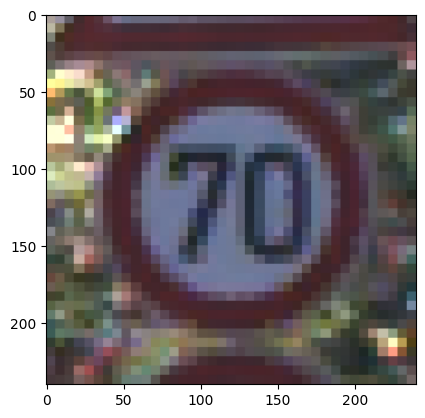

In [4]:
test_images, test_labels = test_generator[0]  # Get a batch
pred = predict_traffic_sign(test_images[0:1],model)
print(pred)
plt.imshow(test_images[0]/255)
plt.show()

In [5]:
import tensorflow as tf

def cw_l2_attack(model, images, labels, targeted=False, c=1e-4, kappa=0, max_iter=1000, learning_rate=0.01):
    images = tf.convert_to_tensor(images)
    labels = tf.convert_to_tensor(labels)
    
    def f(x):
        outputs = model(x)
        num_classes = outputs.shape[-1]
        one_hot_labels = tf.one_hot(labels, depth=num_classes)
        other_logits = (1 - one_hot_labels) * outputs
        i = tf.reduce_max(other_logits, axis=1)
        j = tf.reduce_sum(one_hot_labels * outputs, axis=1)
        
        if targeted:
            return tf.maximum(i - j, -kappa)
        else:
            return tf.maximum(j - i, -kappa)
    
    w = tf.Variable(tf.zeros_like(images), trainable=True)
    optimizer = tf.optimizers.Adam(learning_rate=learning_rate)
    prev_loss = 1e10

    for step in range(max_iter):
        with tf.GradientTape() as tape:
            a = (tf.tanh(w) + 1) / 2
            loss1 = tf.reduce_sum(tf.square(a - images))
            loss2 = c * tf.reduce_sum(f(a))
            total_loss = loss1 + loss2

        gradients = tape.gradient(total_loss, [w])
        optimizer.apply_gradients(zip(gradients, [w]))

        if step % (max_iter//10) == 0:
            if total_loss.numpy() > prev_loss:
                print('Attack Stopped due to CONVERGENCE....')
                return (tf.tanh(w) + 1).numpy() / 2
            prev_loss = total_loss.numpy()

        print(f'- Learning Progress: {((step+1)/max_iter*100):.2f}%', end='\r')

    attack_images = (tf.tanh(w) + 1).numpy() / 2
    return attack_images

In [7]:
original_image = tf.expand_dims(test_images[0], axis=0)
original_image = original_image / 255
adv = cw_l2_attack(model, original_image, 3, targeted=True, c=10, kappa=20, max_iter=1000, learning_rate=0.005)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
(1, 43)
('Keep right', 0.91004467)


TypeError: Invalid shape (1, 240, 240, 3) for image data

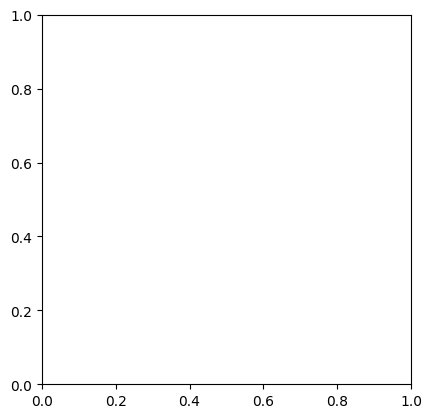

In [8]:
pred_adv = predict_traffic_sign(adv,model)
print(pred_adv)
plt.imshow(adv)
plt.show()